# 43 — Concordancia espaciotemporal TS-MULE × CONFETTI

¿Qué fracción de los timesteps que CONFETTI modifica cae dentro de la ventana
que TS-MULE identifica como relevante?

**Nota conceptual:** ambos métodos responden preguntas distintas. CONFETTI determina
qué cambios mínimos modificarían la predicción; TS-MULE identifica qué regiones
son más importantes para la predicción original. Una alta concordancia es una
condición favorable, pero su ausencia no implica inconsistencia entre los métodos.

## 1. Configuración

In [1]:
import numpy as np
import pickle
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import os

# Cambiar m_id para analizar otra instancia
m_id = 39

PATH_TSMULE = rf'RESULTADOS_TSMULE\_resultados_tsmule_m{m_id}.npz'
PATH_CF     = rf'RESULTADOS_CONFETTI\_resultados_cf_m{m_id}.pkl'
SAVE        = r'RESULTADOS_COMPARACION'
os.makedirs(SAVE, exist_ok=True)

feature_names = ['Boya 1', 'Boya 2', 'Boya 3', 'Boya 4', 'Boya 5', 'Boya 6']
print(f'Instancia: m={m_id}')

Instancia: m=39


## 2. Cargar resultados

In [3]:
try:
    data = np.load(PATH_TSMULE)
    resultados_tsmule = {
        'relevance_promedio': data['relevance_promedio'],
        'relevances_all':     data['relevances_all'],
        'x_perturbed':        data['x_perturbed'],
        'x_original':         data['x_original'],
        'mask':               data['mask'],
    }
    print('TS-MULE cargado.')
except Exception as e:
    if 'resultados_tsmule' in globals(): print('TS-MULE: usando variable en memoria.')
    else: raise FileNotFoundError(e)

try:
    with open(PATH_CF, 'rb') as fh:
        resultados_cf = pickle.load(fh)
    print('CONFETTI cargado.')
except Exception as e:
    if 'resultados_cf' in globals(): print('CONFETTI: usando variable en memoria.')
    else: raise FileNotFoundError(e)

x_original  = np.asarray(resultados_tsmule['x_original'],  float)
x_perturbed = np.asarray(resultados_tsmule['x_perturbed'], float)
instance    = np.asarray(resultados_cf['instance'],         float)

best_cf = resultados_cf.get('best_cf')
if isinstance(best_cf, dict):
    for k in ['cf', 'counterfactual', 'x_cf', 'series', 'data']:
        if k in best_cf:
            best_cf = np.asarray(best_cf[k], float)
            break
best_cf = np.squeeze(np.asarray(best_cf, float))

T, F = x_original.shape
print(f'T={T}, F={F}')

TS-MULE cargado.
CONFETTI cargado.
T=241, F=6


## 3. Máscaras binarias

In [4]:
# Mismo criterio que comparison_plots.py — coherencia con los gráficos del notebook 31
mask_mule = np.abs(x_original - x_perturbed) > 1e-10   # (T, F) bool
mask_cf   = np.abs(best_cf - instance) > 1e-6           # (T, F) bool

print(f'TS-MULE  activo: {mask_mule.mean():.1%} de las celdas')
print(f'CONFETTI activo: {mask_cf.mean():.1%} de las celdas')

TS-MULE  activo: 21.5% de las celdas
CONFETTI activo: 10.2% de las celdas


## 4. Métricas de concordancia

$$\text{IoU}(f) = \frac{|M_\text{MULE}^f \cap M_\text{CF}^f|}
                        {|M_\text{MULE}^f \cup M_\text{CF}^f|}$$

El **recall** es el número principal: de los timesteps que CONFETTI modifica,
qué fracción cae dentro de la ventana de TS-MULE.

In [5]:
def iou_metrics(a, b):
    inter = np.logical_and(a, b).sum()
    union = np.logical_or(a, b).sum()
    iou   = inter / union if union > 0 else 0.0
    prec  = inter / a.sum() if a.sum() > 0 else 0.0
    rec   = inter / b.sum() if b.sum() > 0 else 0.0
    return float(iou), float(prec), float(rec)

print(f'{"Boya":<8} {"IoU":>6} {"Prec":>6} {"Recall":>7} {"MULE%":>7} {"CF%":>6} {"Traslape%":>10}')
print('-' * 55)

resultados_iou = {}
for f, fn in enumerate(feature_names):
    iou, prec, rec = iou_metrics(mask_mule[:, f], mask_cf[:, f])
    m_pct = mask_mule[:, f].mean()
    c_pct = mask_cf[:, f].mean()
    overlap_pct = np.logical_and(mask_mule[:, f], mask_cf[:, f]).mean()
    resultados_iou[fn] = {'iou': iou, 'precision': prec, 'recall': rec,
                          'mule_pct': m_pct, 'cf_pct': c_pct,
                          'overlap_pct': overlap_pct}
    print(f'{fn:<8} {iou:>6.3f} {prec:>6.3f} {rec:>7.3f} '
          f'{m_pct:>7.1%} {c_pct:>6.1%} {overlap_pct:>10.1%}')

iou_g, prec_g, rec_g = iou_metrics(mask_mule.ravel(), mask_cf.ravel())
ov_g = np.logical_and(mask_mule, mask_cf).mean()
print('-' * 55)
print(f'{"GLOBAL":<8} {iou_g:>6.3f} {prec_g:>6.3f} {rec_g:>7.3f} '
      f'{mask_mule.mean():>7.1%} {mask_cf.mean():>6.1%} {ov_g:>10.1%}')

Boya        IoU   Prec  Recall   MULE%    CF%  Traslape%
-------------------------------------------------------
Boya 1    0.161  0.281   0.273   13.3%  13.7%       3.7%
Boya 2    0.096  0.107   0.474   34.9%   7.9%       3.7%
Boya 3    0.116  0.192   0.227   10.8%   9.1%       2.1%
Boya 4    0.197  0.261   0.444   19.1%  11.2%       5.0%
Boya 5    0.087  0.099   0.409   37.8%   9.1%       3.7%
Boya 6    0.120  0.188   0.250   13.3%  10.0%       2.5%
-------------------------------------------------------
GLOBAL    0.123  0.161   0.340   21.5%  10.2%       3.5%


## 5. Visualización — traslape por boya

Guardado: RESULTADOS_COMPARACION\traslape_iou.png


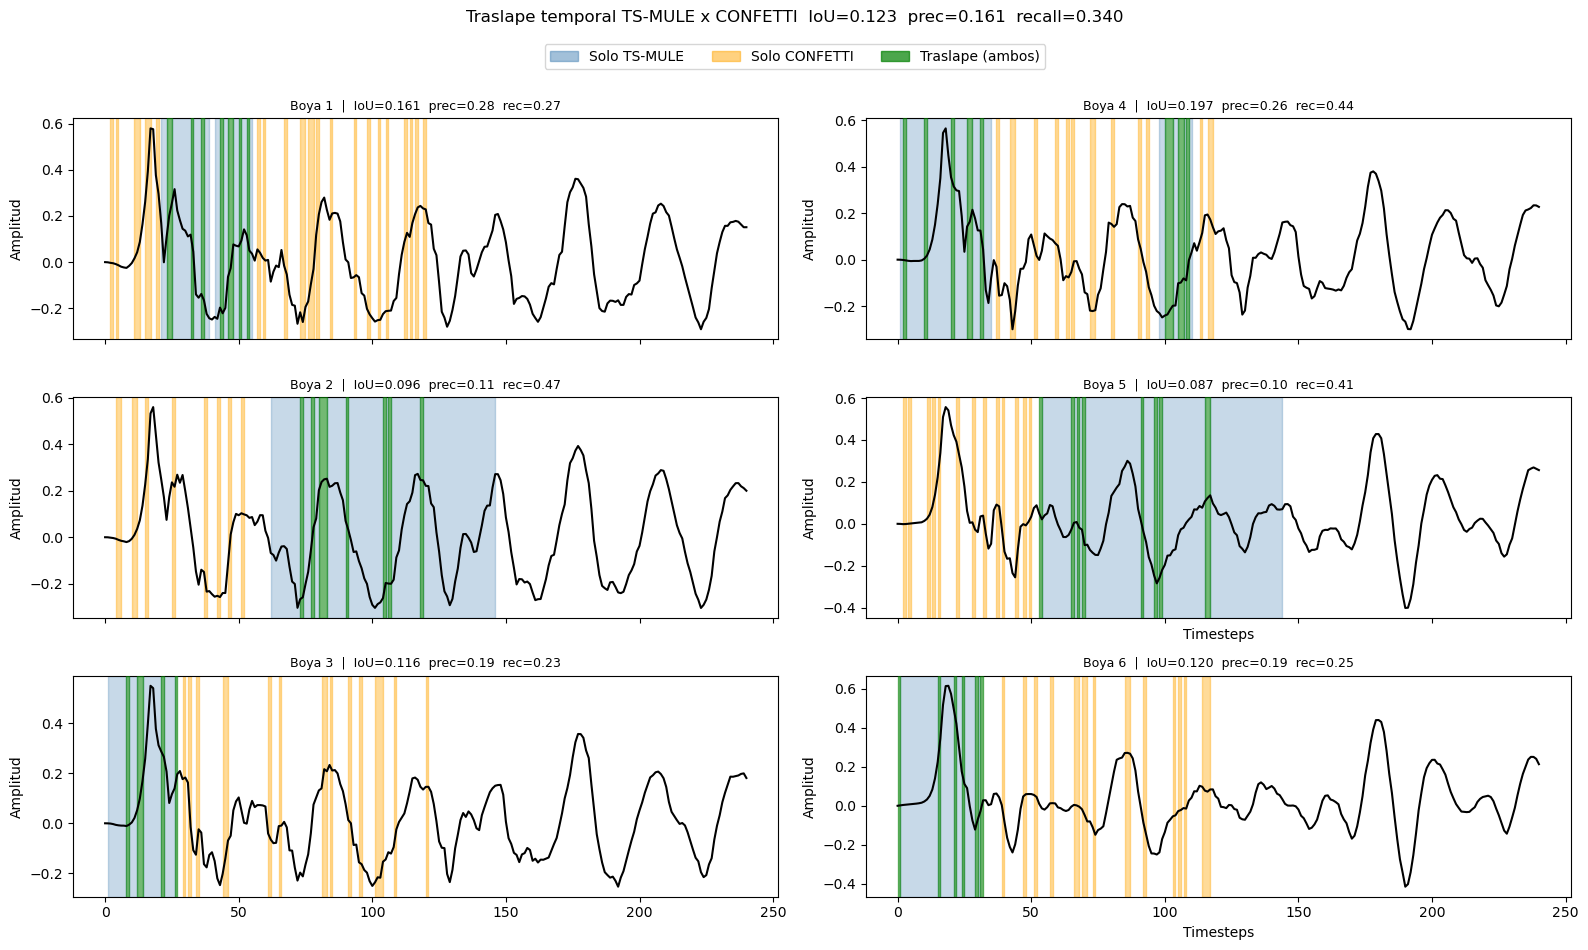

In [6]:
fig, axes = plt.subplots(3, 2, figsize=(16, 9), sharex=True)
axes = axes.T.ravel()

for f, (ax, fn) in enumerate(zip(axes, feature_names)):
    t = np.arange(T)

    solo_mule = (mask_mule[:, f] & ~mask_cf[:, f])
    solo_cf   = (~mask_mule[:, f] & mask_cf[:, f])
    ambos     = (mask_mule[:, f] & mask_cf[:, f])

    def _spans(mask_1d):
        spans, in_span, start = [], False, 0
        for i, v in enumerate(mask_1d):
            if v and not in_span:
                start, in_span = i, True
            elif not v and in_span:
                spans.append((start, i)); in_span = False
        if in_span:
            spans.append((start, len(mask_1d)))
        return spans

    for lo, hi in _spans(solo_mule):
        ax.axvspan(lo, hi, alpha=0.30, color='steelblue', zorder=1)
    for lo, hi in _spans(solo_cf):
        ax.axvspan(lo, hi, alpha=0.40, color='orange', zorder=2)
    for lo, hi in _spans(ambos):
        ax.axvspan(lo, hi, alpha=0.55, color='green', zorder=3)

    ax.plot(t, x_original[:, f], color='black', lw=1.5, zorder=4)

    r = resultados_iou[fn]
    ax.set_title('{fn}  |  IoU={iou:.3f}  prec={prec:.2f}  rec={rec:.2f}'.format(
        fn=fn, iou=r['iou'], prec=r['precision'], rec=r['recall']), fontsize=9)
    ax.set_ylabel('Amplitud')

for ax in axes[4:]:
    ax.set_xlabel('Timesteps')

p_mule = mpatches.Patch(color='steelblue', alpha=0.5, label='Solo TS-MULE')
p_cf   = mpatches.Patch(color='orange',    alpha=0.5, label='Solo CONFETTI')
p_both = mpatches.Patch(color='green',     alpha=0.7, label='Traslape (ambos)')
fig.legend(handles=[p_mule, p_cf, p_both], loc='upper center',
           ncol=3, fontsize=10, bbox_to_anchor=(0.5, 1.02))
fig.suptitle(
    'Traslape temporal TS-MULE x CONFETTI  '
    'IoU={iou:.3f}  prec={prec:.3f}  recall={rec:.3f}'.format(
        iou=iou_g, prec=prec_g, rec=rec_g),
    fontsize=12, y=1.05)
plt.tight_layout()
fname = os.path.join(SAVE, 'traslape_iou.png')
fig.savefig(fname, dpi=130, bbox_inches='tight')
print('Guardado:', fname)
plt.show()

## 6. Panel m=39 vs m=62

In [7]:
def iou_panel(m_id):
    pt = rf'RESULTADOS_TSMULE\_resultados_tsmule_m{m_id}.npz'
    pc = rf'RESULTADOS_CONFETTI\_resultados_cf_m{m_id}.pkl'
    if not os.path.exists(pt) or not os.path.exists(pc):
        print(f'm={m_id}: archivos no encontrados.')
        return None
    d = np.load(pt)
    rt = {k: d[k] for k in d.files}
    with open(pc, 'rb') as fh: rc = pickle.load(fh)
    xo  = np.asarray(rt['x_original'],  float)
    xp  = np.asarray(rt['x_perturbed'], float)
    ins = np.asarray(rc['instance'],     float)
    bcf = rc.get('best_cf')
    if isinstance(bcf, dict):
        for k in ['cf','counterfactual','x_cf','series','data']:
            if k in bcf: bcf = np.asarray(bcf[k], float); break
    bcf = np.squeeze(np.asarray(bcf, float))
    mm  = np.abs(xo - xp)  > 1e-10
    mc  = np.abs(bcf - ins) > 1e-6
    iou, prec, rec = iou_metrics(mm.ravel(), mc.ravel())
    ov  = np.logical_and(mm, mc).mean()
    print(f'm={m_id}: IoU={iou:.3f}  prec={prec:.3f}  recall={rec:.3f}  '
          f'traslape={ov:.1%}  MULE={mm.mean():.1%}  CF={mc.mean():.1%}')
    return {'iou': iou, 'prec': prec, 'rec': rec,
            'mule': mm.mean(), 'cf': mc.mean(), 'overlap': ov}

print(f'{"m":>4} {"IoU":>6} {"Prec":>6} {"Recall":>7} {"MULE%":>7} {"CF%":>6} {"Traslape%":>10}')
print('-' * 52)
for m_id in [39, 62]:
    iou_panel(m_id)

   m    IoU   Prec  Recall   MULE%    CF%  Traslape%
----------------------------------------------------
m=39: IoU=0.123  prec=0.161  recall=0.340  traslape=3.5%  MULE=21.5%  CF=10.2%
m=62: IoU=0.104  prec=0.116  recall=0.500  traslape=4.6%  MULE=39.8%  CF=9.3%
